# PCA and Hierarchical Clustering

In [1]:
# --- 1. CORE DATA & VIZ ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
%matplotlib inline

# --- 2. STATSMODELS (Statistical Inference & Formulas) ---
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm
from statsmodels.nonparametric.smoothers_lowess import lowess
# --- (Multiple Testing) ---
from scipy.stats import (ttest_1samp, ttest_rel, ttest_ind, t as t_dbn)
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests as mult_test


# --- 3. SKLEARN: PREPROCESSING & DATA PIPELINES ---
from sklearn.model_selection import (
    train_test_split, LeaveOneOut, KFold, 
    cross_val_score, GridSearchCV, RandomizedSearchCV)

from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, PolynomialFeatures, OneHotEncoder)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# --- 4. SKLEARN: LINEAR MODELS (Chapter 3, 4, & 6) ---
from sklearn.linear_model import (
    LinearRegression, LogisticRegression, 
    Ridge, Lasso, ElasticNet, RidgeCV, LassoCV)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# --- 5. SKLEARN: MODEL SELECTION & DIMENSIONALITY REDUCTION (Chapter 6) ---
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

# --- 6. SKLEARN: TREE-BASED MODELS & ENSEMBLES (Chapter 8) ---
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier, HistGradientBoostingClassifier,
    BaggingRegressor, BaggingClassifier, AdaBoostRegressor)

# --- 7. SKLEARN: SUPPORT VECTOR MACHINES (Chapter 9) ---
from sklearn.svm import SVC, SVR, LinearSVC
from sklearn.inspection import DecisionBoundaryDisplay

# --- 8. SKLEARN: NEAREST NEIGHBORS & CLUSTERING (Chapter 4 & 12) ---
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import cut_tree, dendrogram, linkage, fcluster  

# --- 9. SKLEARN: EVALUATION METRICS ---
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error, precision_score, recall_score, 
    f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, 
    roc_curve, auc, roc_auc_score,RocCurveDisplay, silhouette_score)

# --- 10. UTILS & RESAMPLING ---
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')
from patsy import (dmatrix, bs)

# --- 11. SURVIVAL ANALYSIS (Industry Standard) ---
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

# Review of Hypothesis Tests

This section of the lab covers **Multiple Testing** (specifically reviewing hypothesis testing, p-values, and Type I/Type II errors under simulation).

The goal here is to demonstrate what happens when you run **100 independent t-tests simultaneously**. It illustrates a fundamental statistical reality: if you run enough tests, you are guaranteed to find false positives (Type I errors) purely by chance, and if your signal is weak, you will miss true effects (Type II errors).

## 1. Setting Up the Simulation Data

* **`X = rng.standard_normal((10, 100))`**: This creates a 2D matrix of random numbers drawn from a standard normal distribution (mean = 0, variance = 1). The shape is 10 rows (observations) by 100 columns (features/variables).
* **`true_mean`**: A vector of length 100. The first 50 elements are `0.5`, and the last 50 elements are `0`.
* **`X += true_mean[None,:]`**: This uses NumPy broadcasting to shift the mean of each column. 
    * **Columns 0 to 49** now have a true mean of 0.5 (The null hypothesis is **false**).
    * **Columns 50 to 99** retain a true mean of 0 (The null hypothesis is **true**).

In [2]:
rng = np.random.default_rng(12)

X = rng.standard_normal((10, 100)) # 10 Observation (Rows) by 100 Features (Columns)

true_mean = np.array([0.5]*50 + [0]*50)
X += true_mean[None,:]

## 2. Testing a Single Variable

* **`ttest_1samp(X[:,0], 0)`**: Performs a one-sample t-test on the very first column (`X[:,0]`) against a population mean of 0.
* **The Result**: The p-value is `0.931`. Because $0.931 > 0.05$, we fail to reject the null hypothesis ($H_0: \mu = 0$).
* **The "Why"**: We know the true mean of this column is actually 0.5. Because the sample size is so small ($n=10$) and the signal is weak, random noise masked the effect. Failing to reject a false null hypothesis is a **Type II error (a false negative)**.

In [3]:
result = ttest_1samp(X[:,0], 0)
result.pvalue

np.float64(0.9307442156164141)

## 3. Evaluating 100 Tests & Building the Evaluation Table

**`pd.cut`** categorizes the continuous p-values into discrete bins:
* From 0 to 0.05 $\rightarrow$ `'Reject H0'` (statistically significant).
* From 0.05 to 1.0 $\rightarrow$ `'Do not reject H0'` (not significant).

In [4]:
p_values = np.empty(100)

for i in range(100):
    p_values[i] = ttest_1samp(X[:,i], 0).pvalue
decision = pd.cut(p_values, [0, 0.05, 1], 
                  labels=['Reject H0','Do not reject H0']
)
truth = pd.Categorical(true_mean == 0,
                       categories=[False, True], ordered=True
)

In [5]:
pd.crosstab(decision, truth, rownames = ['Decision'], colnames = ['H_o']).T

Decision,Reject H0,Do not reject H0
H_o,,
False,15,35
True,5,45


### Analysis of Scenario 1 (Weak Signal: Mean = 0.5)

> * **Type I Errors (5)**: For the 50 variables where the null hypothesis was completely true, we rejected $H_0$ five times. Why? Because we set our significance threshold $\alpha = 0.05$. By definition, $5\%$ of $50$ true nulls is $2.5$. Finding 5 false positives is entirely expected due to random sampling variation.
> * **Type II Errors (35)**: Out of the 50 variables where an effect did exist, we missed 35 of them. This is because a mean shift of 0.5 with only 10 samples represents low statistical power. The signal-to-noise ratio is too small to consistently flag.

## 4. Scenario 2: Strengthening the Signal (Mean = 1.0)

### What changed and why?

* **Type II Errors dropped from 35 to 10**: Because the true mean is now 1.0, the effect size is twice as large. Even with a tiny sample size ($n=10$), the t-test can easily separate the real effects from the noise. Our statistical power increased dramatically.
* **Type I Errors dropped from 5 to 2**: For the columns where the mean is 0, nothing changed in the data generation process. We still expect roughly $5\%$ of the 50 true nulls to be falsely rejected ($\approx 2.5$). Finding 2 instead of 5 is just standard simulation noise.

In [6]:
true_mean = np.array([1]*50 + [0]*50)

In [7]:
X = rng.standard_normal((10, 100))
X += true_mean[None,:]
for i in range(100):
    p_values[i] = ttest_1samp(X[:,i], 0).pvalue
decision = pd.cut(p_values, [0, 0.05, 1], 
                  labels=['Reject H0', 'Do not reject H0']
                 )
truth = pd.Categorical(true_mean == 0, categories=[False, True], ordered=True
                      )
pd.crosstab(decision, 
            truth,
            rownames=['Decision'],
            colnames=['H_o']).T

Decision,Reject H0,Do not reject H0
H_o,,
False,40,10
True,2,48


# Family-Wise Error Rate (FWER)

This section of the lab covers the **Family-Wise Error Rate (FWER)** and the mechanics of controlling it when making multiple comparisons.

The goal here is to show that as you test more variables, the probability of making at least one false discovery skyrockets. It introduces **Bonferroni**, **Holm**, and **Tukey's HSD** methods as tools to rein in this error rate.

> **The Trade-off:** Even for moderate values of $m$ (such as 50), the FWER exceeds 0.05 unless $\alpha$ is set to a very low value, such as 0.001. Of course, the problem with setting $\alpha$ to such a low value is that we are likely to make a high number of Type II errors—in other words, our statistical power becomes very low.

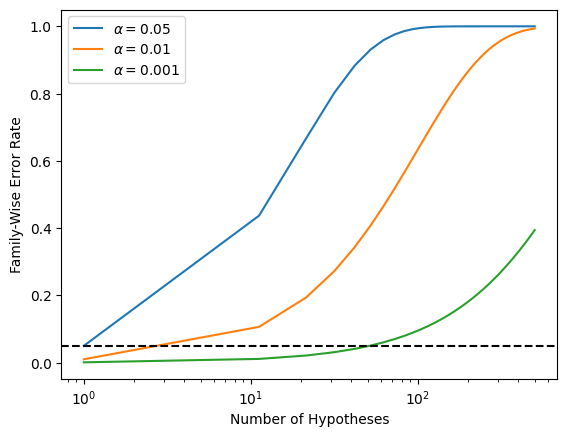

In [8]:
 m = np.linspace(1, 501)
fig, ax = plt.subplots()
[ax.plot(m, 
         1- (1- alpha)**m,
         label=r'$\alpha=%s$' % str(alpha)) 
         for alpha in [0.05, 0.01, 0.001]]
ax.set_xscale('log')
ax.set_xlabel('Number of Hypotheses')
ax.set_ylabel('Family-Wise Error Rate')
ax.legend()
ax.axhline(0.05, c='k', ls='--');

In [9]:
Fund = pd.read_csv("Fund.csv")
Fund.head()

,Manager1,Manager2,Manager3,Manager4,Manager5,Manager6,Manager7,Manager8,Manager9,Manager10,...,Manager1991,Manager1992,Manager1993,Manager1994,Manager1995,Manager1996,Manager1997,Manager1998,Manager1999,Manager2000
0,-3.341992,-4.167469,9.389223,8.417220,0.997863,7.191473,-10.767592,4.072425,1.575264,-0.798505,...,-2.948706,10.350706,-2.855337,-4.431786,0.739544,0.198044,1.752188,-1.534710,-3.359419,6.585654
1,3.759627,12.525254,3.403366,0.143944,-7.222227,0.067747,-10.737053,-1.138185,-7.166604,4.778522,...,24.003150,-1.966606,-1.609109,1.405325,4.717175,1.540359,-12.218233,-0.073008,-8.547683,-2.382629
2,12.970091,-2.581061,-0.824734,6.584604,17.050241,1.857130,3.196942,-7.981362,-1.214148,2.338250,...,-2.926914,6.420147,8.946921,3.449013,1.009957,1.481369,14.203314,0.005562,-5.105035,2.292429
3,-4.874630,7.981743,-4.026743,-4.731946,0.503276,0.740187,-28.969410,4.683751,-0.568840,-4.000547,...,-3.112208,3.173581,-6.017109,-1.984873,1.022525,-2.261927,19.345970,-1.048299,-0.016154,1.196832
4,2.019279,-5.370236,-4.854669,10.594432,-6.891574,9.877838,1.430033,9.840311,5.311455,18.365094,...,7.173653,-9.157211,7.643125,-1.022339,-1.325865,2.848785,-6.642081,2.488612,0.032060,-7.510032


## 1. Testing 5 Mutual Fund Managers

We conduct a one-sample t-test for each of the first five managers in the `Fund` dataset to test the null hypothesis that the $j$-th fund manager’s mean return equals zero ($H_{0,j} : \mu_j = 0$). We loop 5 times, computing a raw p-value for each manager.

* **The Result:** Manager 1 (`0.006`) and Manager 3 (`0.012`) both have individual p-values well below 0.05.
* **The Problem:** If we stop here and claim both managers are statistically significant, we are ignoring the fact that we ran 5 tests simultaneously. We must adjust these p-values to guarantee that our overall FWER remains below 0.05.

In [10]:
fund_mini = Fund.iloc[:,:5]
fund_mini_pvals = np.empty(5)
for i in range(5):
    fund_mini_pvals[i] = ttest_1samp(fund_mini.iloc[:,i], 0).pvalue
    
fund_mini_pvals

array([0.00620236, 0.91827115, 0.01160098, 0.6005396 , 0.75578151])

## 2. FWER Control Methods

### Method A: Bonferroni Correction
The Bonferroni correction is the simplest approach: to maintain an overall FWER of $\alpha$, it multiplies each raw p-value by the total number of tests $m$. 
* Under this approach, **Manager 1 remains significant** ($0.006 \times 5 = 0.03 \le 0.05$), but **Manager 3 is lost** ($0.012 \times 5 = 0.06 > 0.05$).

In [11]:
reject, bonf = mult_test(fund_mini_pvals, method = "bonferroni")[:2]
reject

array([ True, False, False, False, False])

In [12]:
bonf, np.minimum(fund_mini_pvals * 5, 1)

(array([0.03101178, 1.        , 0.05800491, 1.        , 1.        ]),
 array([0.03101178, 1.        , 0.05800491, 1.        , 1.        ]))

### Method B: Holm's Method (Step-Down)
Bonferroni is notoriously conservative and frequently throws away too much statistical power. Holm's Method provides a smarter approach by sorting p-values sequentially and applying sequentially relaxed multipliers.

In [13]:
mult_test(fund_mini_pvals, method = "holm", alpha=0.05)[:2]

(array([ True, False,  True, False, False]),
 array([0.03101178, 1.        , 0.04640393, 1.        , 1.        ]))

## 3. Why did Holm find Manager 3 significant while Bonferroni did not?

Holm works sequentially using the following logic:

1. **Sort:** It sorts raw p-values from smallest to largest: `0.006` (M1), `0.012` (M3), ...
2. **Step 1:** Evaluates the smallest p-value first with the full multiplier ($m=5$): 
   $$0.006 \times 5 = 0.03 \rightarrow \text{Reject } H_0 \text{ (Significant)}$$
3. **Step 2:** Evaluates the next smallest, but relaxes the penalty multiplier to ($m-1=4$): 
   $$0.012 \times 4 = 0.048 \rightarrow \text{Reject } H_0 \text{ (Significant)}$$

**Conclusion:** Because Holm adjusts sequentially rather than globally, it preserves more statistical power. This allows us to successfully discover both Manager 1 and Manager 3 without inflating our overall 5% family-wise error rate.

## 4. Pairwise Comparisons & The "Data-Snooping" Trap

In [14]:
fund_mini.mean()

Manager1    3.0
Manager2   -0.1
Manager3    2.8
Manager4    0.5
Manager5    0.3
dtype: float64

In [15]:
ttest_rel(fund_mini['Manager1'], fund_mini['Manager2']).pvalue

np.float64(0.038391072368079586)

After examining the data, suppose we perform a paired t-test directly comparing the best-performing manager (Manager 1) with the worst-performing manager (Manager 2).

* **The Trap:** The test results in a raw p-value of `0.038`, which initially looks statistically significant. **But this is a trap.** 
* **Data-Snooping:** We only decided to run this specific test *after* looking at the data and noting who had the highest and lowest mean performances. 
* **The Reality:** With 5 managers, there are actually $\binom{5}{2} = 10$ possible pairs we could have chosen to compare. By cherry-picking the extreme pair, we are implicitly performing multiple testing without adjusting for it.

### Tukey’s Honest Significant Difference (HSD)

To properly account for looking at all pairwise choices, we apply **Tukey's HSD method**. This test automatically controls the FWER across all 10 potential group comparisons simultaneously.

> **The Verdict:** When running Tukey's HSD on this data, the adjusted p-value for the Manager 1 vs. Manager 2 comparison spikes from **0.038** up to **0.186** (failing to reject $H_0$). The apparent difference disappears into the background noise, proving that our original significant finding was a false positive driven entirely by data-snooping.

In [16]:
returns = np.hstack([fund_mini.iloc[:,i] for i in range(5)])
managers = np.hstack([[i+1]*50 for i in range(5)])
tukey = pairwise_tukeyhsd(returns, managers)
print(tukey.summary())

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     1      2     -3.1 0.1862 -6.9865 0.7865  False
     1      3     -0.2 0.9999 -4.0865 3.6865  False
     1      4     -2.5 0.3948 -6.3865 1.3865  False
     1      5     -2.7 0.3152 -6.5865 1.1865  False
     2      3      2.9 0.2453 -0.9865 6.7865  False
     2      4      0.6 0.9932 -3.2865 4.4865  False
     2      5      0.4 0.9986 -3.4865 4.2865  False
     3      4     -2.3  0.482 -6.1865 1.5865  False
     3      5     -2.5 0.3948 -6.3865 1.3865  False
     4      5     -0.2 0.9999 -4.0865 3.6865  False
---------------------------------------------------


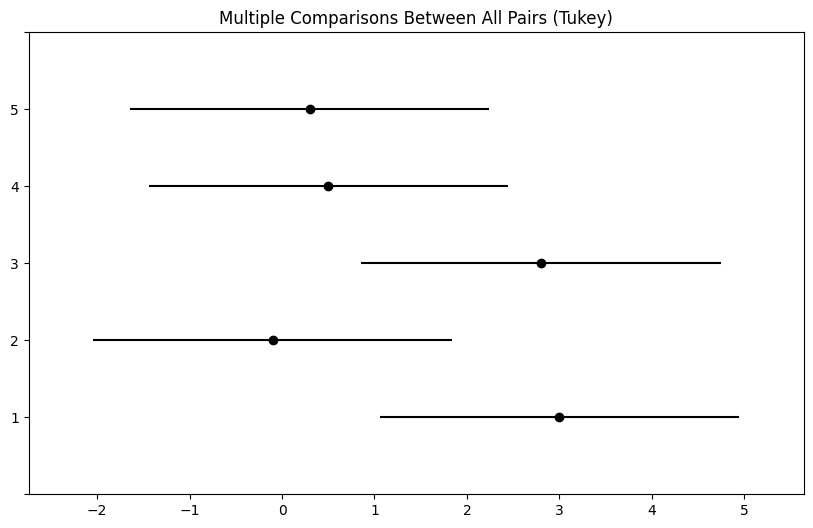

In [17]:
fig, ax = plt.subplots(figsize=(8,8))
tukey.plot_simultaneous(ax=ax);

To run the multiple comparison test, the data must be reformatted into a long format so the algorithm can understand group assignments.

* **`np.hstack([...])`**: Groups the data into a long format. 
    * `returns`: Stacks all 250 return observations (50 months $\times$ 5 managers) into a single 1D array. 
    * `managers`: Creates a matching 1D array acting as a categorical label, indicating which return belongs to which group (1 through 5).
* **`pairwise_tukeyhsd(returns, managers)`**: Automatically evaluates all 10 pairwise combinations against each other, properly adjusting the p-values for the fact that 10 comparisons are happening simultaneously.

---

### (`tukey.summary()`)

If you look at the first row of the summary output table (which explicitly compares **Group 1** to **Group 2**):

| Group 1 | Group 2 | meandiff | p-adj | lower | upper | reject |
| :--- | :--- | :---: | :---: | :---: | :---: | :---: |
| 1 | 2 | -3.1 | **0.186** | -6.9865 | 0.7865 | **False** |

* **`meandiff: -3.1`**: The observed difference in mean returns between the two managers.
* **`p-adj: 0.186`**: The adjusted p-value after accounting for the simultaneous multi-group comparison.
* **`reject: False`**: The formal statistical decision.

When properly adjusted for the 10 pairwise choices we implicitly made by scrolling through the data, the adjusted p-value spikes to **0.186** (well above our 0.05 threshold). The apparent difference between the best and worst manager completely disappears into the background noise, proving that our original paired t-test was a false positive driven entirely by data-snooping.

# Controlling the False Discovery Rate (FDR): Benjamini–Hochberg (BH)

This section transitions from controlling the Family-Wise Error Rate (FWER) to controlling the **False Discovery Rate (FDR)**.

When you scale up from 5 managers to **2,000 managers**, strict FWER methods like Bonferroni become too harsh—they completely kill your statistical power, resulting in zero discoveries. Instead, the **Benjamini–Hochberg (BH)** procedure is used to control the *proportion of false discoveries* among your accepted results.

In [18]:
fund_pvalues = np.empty(2000)
for i, manager in enumerate(Fund.columns):
    fund_pvalues[i] = ttest_1samp(Fund[manager], 0).pvalue

## 1. Generating & Interpreting q-Values

* **What is a q-value?** A q-value of 0.1 means: *"If you reject this null hypothesis, you are accepting a 10% overall False Discovery Rate among all your rejections."*
* **The Cutoff:** By thresholding `fund_qvalues <= 0.1`, we find **146 managers** whose performance is statistically meaningful.
* **The Interpretation:** We can confidently declare these 146 managers as "market beaters." Controlling the FDR at 10% implies that roughly 10% of our discoveries are likely fluke positives. That means out of 146 selected managers, about 15 are probably noise ($146 \times 0.1$), but the remaining $\approx 131$ are genuinely skilled.

In [19]:
fund_qvalues = mult_test(fund_pvalues, method = "fdr_bh")[1]
fund_qvalues[:10]

array([0.08988921, 0.991491  , 0.12211561, 0.92342997, 0.95603587,
       0.07513802, 0.0767015 , 0.07513802, 0.07513802, 0.07513802])

In [20]:
(fund_qvalues <= 0.1).sum()

np.int64(146)

## 2. Under the Hood: The Mathematical Logic

To demystify how `mult_test(..., method="fdr_bh")` calculates these thresholds, we can rebuild the underlying logic step-by-step. 

The Benjamini–Hochberg rule states that you sort your $m$ individual p-values in ascending order ($p_{(1)} \le p_{(2)} \le \dots \le p_{(m)}$) and find the **largest index $j$** where the following condition holds:

$$p_{(j)} \le \frac{j}{m} \times q$$

Once you identify that largest index $j$, you reject the null hypothesis ($H_0$) for that specific test **and every single test ranked below it**.

In [21]:
sorted_ = np.sort(fund_pvalues)
m = fund_pvalues.shape[0]
q = 0.1
sorted_set_ = np.where(sorted_ < q * np.linspace(1, m, m) / m)[0]
if sorted_set_.shape[0] > 0:
    selected_ = fund_pvalues < sorted_[sorted_set_].max()
    sorted_set_ = np.arange(sorted_set_.max())
else:
    selected_ = []
    sorted_set_ = []

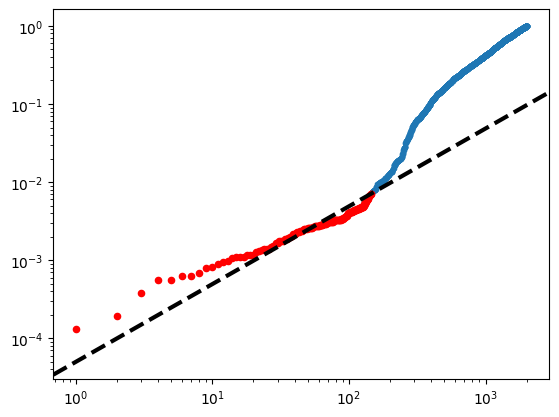

In [22]:
fig, ax = plt.subplots()
ax.scatter(np.arange(0, sorted_.shape[0]) + 1, sorted_, s=10)
ax.set_yscale('log')
ax.set_xscale('log')
ax.scatter(sorted_set_+1, sorted_[sorted_set_], c='r', s=20)
ax.axline((0, 0), (1, q/m), c='k', ls='--', linewidth=3);

## 3. Visualizing the Threshold Line

When plotting the sorted p-values against their ranked indexes on a log-log scale, we draw a boundary line to isolate our discoveries:

* **`ax.axline((0,0), (1, q/m))`**: Draws the linear Benjamini–Hochberg boundary line starting from the origin $(0,0)$ with a slope of $\frac{q}{m}$ (which means at rank index 1, the critical height threshold is $\frac{0.1}{2000}$).
* **The Selection:** Any p-value point that sits **below or to the right** of this line successfully satisfies the criteria and is dragged into our collection of rejections. This visual cutoff makes it easy to see exactly why those 146 specific managers were declared significant.

# Re-Sampling Approach

This section of the lab covers **Resampling-Based Hypothesis Testing** (specifically **Permutation Tests**).

The goal here is to stop relying on theoretical assumptions (like assuming data perfectly follows a Student's t-distribution) and instead **build an empirical null distribution** by shuffling the data labels. This approach is highly useful when sample sizes are small or when normal distribution assumptions are questionable.

In [23]:
# 1. Load the local CSV files 
xtrain = pd.read_csv('Khan_xtrain.csv', index_col=0)
xtest = pd.read_csv('Khan_xtest.csv', index_col=0)
ytrain = pd.read_csv('Khan_ytrain.csv')
ytest = pd.read_csv('Khan_ytest.csv')

# 2. Merge training and testing data
D = pd.concat([xtrain, xtest])

# FIX: Combine the labels into a clean, flat 1D NumPy array.
# This bypasses all pandas index alignment checks.
Y_combined = np.concatenate([ytrain.values, ytest.values]).flatten()
D['Y'] = Y_combined

# Verify the class distributions match the lab profile
print("Class counts:\n", D['Y'].value_counts())

Class counts:
 Y
2    29
4    25
3    18
1    11
Name: count, dtype: int64


In [24]:
# 3. Isolate the two target cancer classes (Class 2 and Class 4)
D2 = D[D['Y'] == 2]
D4 = D[D['Y'] == 4]

# FIX: Dynamically identify the column name of the gene 
# (Index 9 is the 10th column since python uses 0-based indexing)
gene_11 = D.columns[9]
print(f"The 11th gene column is actually named: '{gene_11}'")

# 4. Run the baseline independent t-test using our found column name
observedT, pvalue = ttest_ind(D2[gene_11], D4[gene_11], equal_var=True)

print(f'\nObserved T-statistic: {observedT:.2f}')
print(f'Theoretical P-value: {pvalue:.4f}')

The 11th gene column is actually named: 'V11'

Observed T-statistic: -2.09
Theoretical P-value: 0.0412


## 1. Baseline Theoretical t-Test

* **What it does:** Computes a standard two-sample independent t-test for Gene 11 between Class 2 and Class 4.
* **The Result:** The observed $t$-statistic is `-2.094`, corresponding to a theoretical p-value of `0.041`. This p-value is calculated by mapping the value to a mathematical curve (a $t$-distribution with 52 degrees of freedom).

In [25]:
B = 10000
Tnull = np.empty(B)
D_ = np.hstack([D2[gene_11], D4[gene_11]]) # Pool the data (length 54)
n_ = D2[gene_11].shape[0]                 # n_ = 29
D_null = D_.copy()

for b in range(B):
    rng.shuffle(D_null)                    # Mix up the values completely
    ttest_ = ttest_ind(D_null[:n_], D_null[n_:], equal_var=True)
    Tnull[b] = ttest_.statistic

(np.abs(Tnull) > np.abs(observedT)).mean()

np.float64(0.0398)

Text(0.5, 0, 'Null Distribution of Test Statistic')

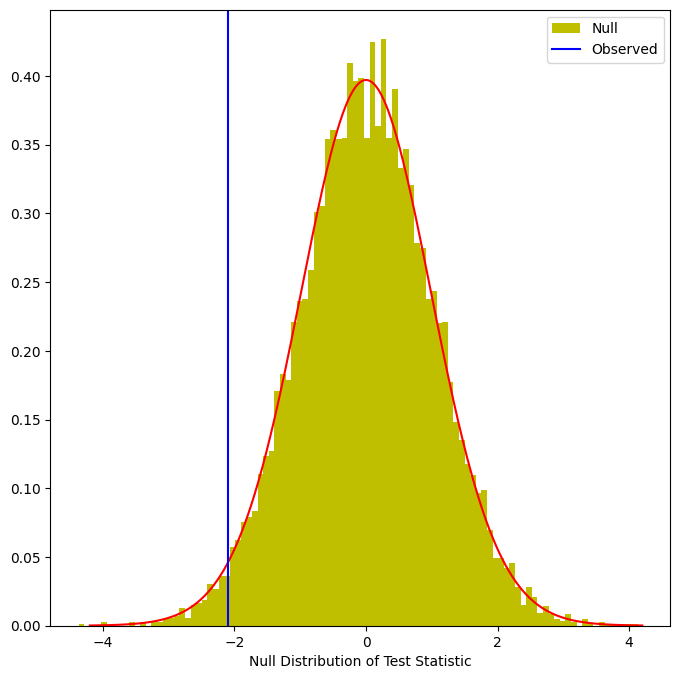

In [26]:
fig, ax = plt.subplots(figsize=(8,8))
ax.hist(Tnull, bins=100, density=True,
        facecolor='y',
        label='Null'
       )
xval = np.linspace(-4.2, 4.2, 1001)
ax.plot(xval, t_dbn.pdf(xval, D_.shape[0]-2), c='r')
ax.axvline(observedT, c='b', label='Observed')
ax.legend()
ax.set_xlabel("Null Distribution of Test Statistic")

## 2. Empirical Permutation Test

By pooling our data, randomly shuffling the labels 10,000 times, and recalculating the test statistics, we generate an empirical baseline to test against:

* **`np.abs(Tnull) > np.abs(observedT)`**: Checks how often our shuffled, randomized data generated a $t$-statistic more extreme (further from 0) than our real-world `observedT` (`-2.094`).
* **`.mean()`**: Calculates the final empirical proportion. Out of 10,000 shuffles, only about 3.98% of them produced an effect this large purely by luck. 
* **The Verdict:** This empirical p-value (`0.0398`) is incredibly close to our theoretical p-value (`0.041`), validating that the theoretical parametric model fits this data well.

In [33]:
m, B = 100, 1000
idx = rng.choice(xtest.columns, m, replace=False)
T_vals = np.empty(m)
Tnull_vals = np.empty((m, B)) # Shape: (100, 10000)

for j in range(m):
    col = idx[j]
    # 1. Compute actual observed t-statistic for gene j
    T_vals[j] = ttest_ind(D2[col], D4[col], equal_var=True).statistic
    
    # 2. Run 10,000 shuffles to get 10,000 null t-statistics for gene j
    D_ = np.hstack([D2[col], D4[col]])
    D_null = D_.copy()
    for b in range(B):
        rng.shuffle(D_null)
        Tnull_vals[j,b] = ttest_ind(D_null[:n_], D_null[n_:], equal_var=True).statistic

## 3. Scaling Up: The Plug-In FDR Approach

Now we want to evaluate multiple genes simultaneously. To save computing time in the lab, we randomly select a subset of $m = 100$ genes and perform 1,000 permutations for each of them.

Instead of picking an arbitrary p-value threshold, the **Plug-In FDR method** uses varying absolute $t$-statistic cutoff points ($c$). For any chosen cutoff value $c$, we calculate:

* $R$ (**Discoveries**): The number of real genes whose real absolute $t$-statistic is $\ge c$.
* $V$ (**Estimated False Positives**): The average number of genes in our shuffled datasets that managed to clear $c$ purely by chance.

$$\text{Estimated FDR} = \frac{V}{R}$$

In [34]:
cutoffs = np.sort(np.abs(T_vals))
FDRs, Rs, Vs = np.empty((3, m))

for j in range(m):
    # How many real genes pass this cutoff?
    R = np.sum(np.abs(T_vals) >= cutoffs[j])
    
    # On average, how many shuffled genes pass this cutoff?
    V = np.sum(np.abs(Tnull_vals) >= cutoffs[j]) / B
    
    Rs[j] = R
    Vs[j] = V
    FDRs[j] = V / R

## 4. Filtering the Significant Genes

To find the genes that satisfy our target error tolerances, we index through our calculated arrays:

* **`FDRs < 0.1`**: Identifies the specific data loops where the calculated false discovery rate safely stayed under 10%.
* **`cutoffs[FDRs < 0.1].min()`**: Finds the exact lowest absolute $t$-statistic threshold required to guarantee that 10% safety margin.
* **Selection:** Any gene with an absolute $t$-statistic higher than or equal to that minimum cutoff is selected. In this lab, it yields **15 genes** (meaning we mathematically expect about 1.5 of them to be false discoveries).

In [35]:
# Genes that meet a strict 10% FDR threshold
sorted(idx[np.abs(T_vals) >= cutoffs[FDRs < 0.1].min()])

['V1049',
 'V1225',
 'V1227',
 'V1228',
 'V1283',
 'V1298',
 'V1697',
 'V1772',
 'V1778',
 'V1879',
 'V2193',
 'V388',
 'V443',
 'V500',
 'V697',
 'V758',
 'V766',
 'V828']

In [36]:
# Genes that meet a looser 20% FDR threshold
sorted(idx[np.abs(T_vals) >= cutoffs[FDRs < 0.2].min()])

['V1049',
 'V1225',
 'V1227',
 'V1228',
 'V1244',
 'V1283',
 'V1298',
 'V167',
 'V1697',
 'V1725',
 'V1772',
 'V1778',
 'V1879',
 'V2016',
 'V2193',
 'V354',
 'V388',
 'V443',
 'V500',
 'V697',
 'V758',
 'V766',
 'V828']

## 5. Visualizing the FDR Trade-Off Curve

The final plot maps out the relationship between our total discoveries and our expected error rate:

* **The Curve:** This creates a clear diagnostic plot showing the exact relationship between the **Number of Rejections ($R$)** on the x-axis and the **False Discovery Rate ($FDR$)** on the y-axis. 
* **The Utility:** It enables researchers to visually select an optimal threshold based on how many false discoveries they are willing to tolerate in their specific study. If you need more candidate genes, you can move right along the curve, acknowledging that your proportion of false positives will rise accordingly.

Text(0, 0.5, 'False Discovery Rate')

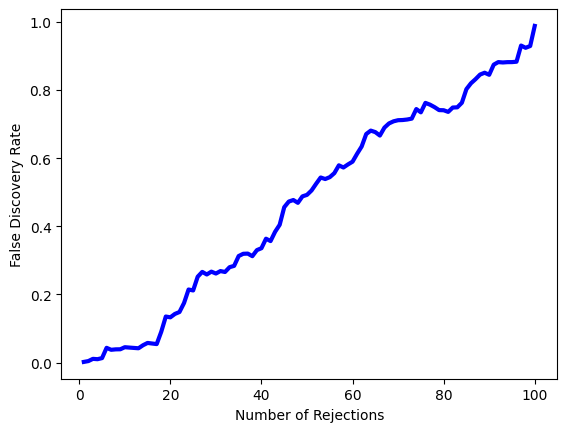

In [37]:
fig, ax = plt.subplots()
ax.plot(Rs, FDRs, 'b', linewidth=3)
ax.set_xlabel("Number of Rejections")
ax.set_ylabel("False Discovery Rate")